# <a name="C1">Importation des données</a>

In [1]:
# Importation des librairies :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st

In [2]:
# Importation des fichiers :
erp = pd.read_csv('/Users/jordancanonne/Library/Mobile Documents/com~apple~CloudDocs/Dossier_principal/Openclassroom/Projet_5/Fichier_erp.csv')
liaison = pd.read_csv('/Users/jordancanonne/Library/Mobile Documents/com~apple~CloudDocs/Dossier_principal/Openclassroom/Projet_5/fichier_liaison.csv')
web = pd.read_csv('/Users/jordancanonne/Library/Mobile Documents/com~apple~CloudDocs/Dossier_principal/Openclassroom/Projet_5/Fichier_web.csv')

In [3]:
# Vérification du nombre de lignes et de colonnes par rapport aux fichiers excel d'origine:
print(erp.shape) # ✔︎
print(liaison.shape) # ✔︎
print(web.shape) # ✔︎ Question ? Est-ce que je dois supprimer en amont sur excel certaines colonnes qui me paraissent inutiles ou le faire directement sur le notebook ?

(825, 5)
(825, 2)
(1513, 28)


# <a name="C2"> Nettoyage des jeux de données</a>

### 1. Erreurs de type

In [4]:
# Vérification du type des variables des 3 dataframes :
print(erp.dtypes) # ✔︎
print('\n')
print(liaison.dtypes) # ✔︎
print('\n')
print(web.dtypes) # ✘  convertir post_date en type date

product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
dtype: object


product_id     int64
id_web        object
dtype: object


sku                       object
virtual                    int64
downloadable               int64
rating_count               int64
average_rating           float64
total_sales              float64
tax_status                object
tax_class                float64
post_author              float64
post_date                 object
post_date_gmt             object
post_content             float64
post_title                object
post_excerpt              object
post_status               object
comment_status            object
ping_status               object
post_password            float64
post_name                 object
post_modified             object
post_modified_gmt         object
post_content_filtered    float64
post_parent              float64
guid                      object
menu

In [5]:
# Raison pour laquelle 'id_web' du df liaison est de type object : 
df_liaison = liaison[liaison['id_web'].apply(lambda x: isinstance(x, str) and not x.isnumeric())]
display(df_liaison)

# Raison pour laquelle 'sku' du df web est de type object : 
df_web = web[web['sku'].apply(lambda x: isinstance(x, str) and not x.isnumeric())]
display(df_web)

# Donc on voit bien que pour les valeurs bon-cadeau-25-euros et 13127-1 on peut les laisser tels qu'elles sont , 
# car elles sont uniques entre le df liaison et web (uniques car : product / attachement à différencier)

,product_id,id_web
443,4954,bon-cadeau-25-euros
822,7247,13127-1
823,7329,14680-1


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
196,bon-cadeau-25-euros,0,0,0,0.0,10.0,taxable,NaN,1.0,2018-06-01 13:53:46,...,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
382,bon-cadeau-25-euros,0,0,0,0.0,10.0,NaN,NaN,1.0,2018-06-01 13:53:46,...,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
490,13127-1,0,0,0,0.0,0.0,NaN,NaN,2.0,2020-06-09 15:42:04,...,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
503,13127-1,0,0,0,0.0,0.0,taxable,NaN,2.0,2020-06-09 15:42:04,...,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [6]:
# Et concernant la valeur 14680-1, nous ne la retrouvons pas dans le df web mais on aurait pû penser que c'est la 
# valeur liée au sku 14680 du df web mais non car il existe une deuxième valeur du df liaison qui et bien égal à 
# la valeur : 14680 existante de les df web et liaison. 
# Vérification des valeurs 14680-1 et 14680 dans le df liason : 
display(liaison.loc[liaison['id_web'] == '14680',:])
display(liaison.loc[liaison['id_web'] == '14680-1',:])

,product_id,id_web
363,4757,14680


,product_id,id_web
823,7329,14680-1


In [7]:
# Convertion du type de la variable 'post_date' du df web (pour correspondre à son format d'origine)  :
web['post_date'] = pd.to_datetime(web['post_date'])

### 2. Valeurs manquantes ou égales à 0

In [8]:
# Vérification des valeurs manquantes 
print(erp.isnull().sum())
print('\n')
print(liaison.isnull().sum())
print('\n')
print(web.isnull().sum())

product_id        0
onsale_web        0
price             0
stock_quantity    0
stock_status      0
dtype: int64


product_id     0
id_web        91
dtype: int64


sku                        85
virtual                     0
downloadable                0
rating_count                0
average_rating             83
total_sales                83
tax_status                797
tax_class                1513
post_author                83
post_date                  83
post_date_gmt              83
post_content             1513
post_title                 83
post_excerpt              797
post_status                83
comment_status             83
ping_status                83
post_password            1513
post_name                  83
post_modified              83
post_modified_gmt          83
post_content_filtered    1513
post_parent                83
guid                       83
menu_order                 83
post_type                  83
post_mime_type            799
comment_count             

In [9]:
# Vérification des valeurs égales à 0 :
print((erp == 0).sum())
print('\n')
print((liaison == 0).sum())
print('\n')
print((web == 0).sum())

product_id          0
onsale_web        108
price               0
stock_quantity    181
stock_status        0
dtype: int64


product_id    0
id_web        0
dtype: int64


sku                         0
virtual                  1513
downloadable             1513
rating_count             1513
average_rating           1430
total_sales               658
tax_status                  0
tax_class                   0
post_author                 0
post_date                   0
post_date_gmt               0
post_content                0
post_title                  0
post_excerpt                0
post_status                 0
comment_status              0
ping_status                 0
post_password               0
post_name                   0
post_modified               0
post_modified_gmt           0
post_content_filtered       0
post_parent              1430
guid                        0
menu_order               1430
post_type                   0
post_mime_type              0
comment_count     

### 4. Changement du nom de la colonne `id_web` en `sku` dans la table de correspondance `liaison`

In [10]:
# Modification du nom de la colonne id_web du df liaison en sku : 
liaison.rename(columns={'id_web': 'sku'}, inplace=True)

### 5.1 Doublons

In [11]:
# Concentrons nous sur les clés primaires des chaques dataframe analysés pécédemment : 
# Affichage des doublons du dataframe erp à partir de la colonne product_id : 
display(erp.loc[erp[['product_id']].duplicated(keep=False),:])
# Observation : 0 valeurs en doublons dans la colonne product_id

,product_id,onsale_web,price,stock_quantity,stock_status


In [12]:
# Affichage des doublons du dataframe liaison à partir de la colonne sku : 
display(liaison.loc[liaison[['sku']].duplicated(keep=False),:])
# Observation : On obtient 91 lignes avec des valeurs manquantes, comme nous vu précédemment dans l'analyse générale

,product_id,sku
19,4055,NaN
49,4090,NaN
50,4092,NaN
119,4195,NaN
131,4209,NaN
...,...,...
817,7196,NaN
818,7200,NaN
819,7201,NaN
820,7203,NaN


In [13]:
# Nombre de valeurs différentes en Doublons dans la Colonne 'sku' du dataframe liaison :
display(len(liaison.loc[liaison['sku'].duplicated(keep=False), 'sku'].unique()))
# Sur 825 valeurs du df liaison, on a 1 valeur différente représentant 91 doublons au total (ctd : Que des valeurs NaN)

1

In [14]:
# Affichage des doublons du dataframe web à partir de la colonne sku et ajout de post_name pour vérifier si des vins 
# existants n'ont pas d'ID (important : car analyse du CA de l'entreprise moins pertinente) : 
display(web.loc[web[['sku','post_name']].duplicated(keep=False),:])
# Observation : On obtient 1511 lignes alors que le df d'origine fait 1513 lignes : 2 lignes sont manquantes

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,16004,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-06-07 16:27:25,...,chateau-du-couvent-pomerol-2017,2020-08-25 18:35:02,2020-08-25 16:35:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,15075,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-14 15:39:43,...,pares-balta-penedes-indigena-2017,2020-08-20 15:35:02,2020-08-20 13:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16209,0,0,0,0.0,6.0,taxable,NaN,2.0,2018-02-14 17:15:31,...,maurel-cabardes-tradition-2017,2020-08-05 18:05:03,2020-08-05 16:05:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
4,15763,0,0,0,0.0,1.0,NaN,NaN,2.0,2020-01-25 14:08:16,...,domaine-de-la-monardiere-vacqueyras-les-vieill...,2020-08-21 11:35:02,2020-08-21 09:35:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,12881,0,0,0,0.0,2.0,NaN,NaN,2.0,2019-03-28 15:25:14,...,montbourgeau-etoile-vin-jaune-2009,2019-12-30 10:30:01,2019-12-30 09:30:01,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1509,15663,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-27 10:27:01,...,chermette-domaine-du-vissoux-brouilly-pierreux...,2020-08-01 09:35:02,2020-08-01 07:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1510,15910,0,0,0,0.0,0.0,taxable,NaN,2.0,2019-03-28 10:59:43,...,thevenet-quintaine-vire-clesse-la-bongran-2015,2020-08-14 10:45:02,2020-08-14 08:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1511,38,0,0,0,0.0,38.0,NaN,NaN,2.0,2018-04-18 12:25:58,...,emile-boeckel-cremant-brut-blanc-de-blancs,2020-08-27 17:15:03,2020-08-27 15:15:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [15]:
# Quasiment toutes les valeurs du dataframe on des doublons (excepté 2). Pourquoi : si on regarde de plus près, 
# on observe qu'il y a une colonne post_type et post_mime_type qui nous indique que chaque produit a un identifiant
# produit et un autre pour les pièces jointes avec une image en format jpeg. 

In [17]:
# Comparaison des valeurs manquantes entre la colonne 'sku' et 'post_name' :
print(web['sku'].isnull().sum())
print(web['post_name'].isnull().sum())

85
83


In [18]:
# Identification des lignes avec des valeurs manquantes dans 'sku' et des valeurs existantes dans 'post_name':

# Sélection des lignes où 'sku' a des valeurs manquantes
valeurs_manquantes_sku = web[web['sku'].isna()]

# Sélection des lignes où 'post_name' a des valeurs existantes parmi les valeurs manquantes de 'sku'
valeurs_existantes_post_name = valeurs_manquantes_sku[valeurs_manquantes_sku['post_name'].notnull()]

# Affichage du DataFrame résultant
display(valeurs_existantes_post_name)

print("Les lignes 353 et 488 du dataframe web n'ont pas d'identifiants mais ont des valeurs associées")

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
353,NaN,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
488,NaN,0,0,0,0.0,10.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


Les lignes 353 et 488 du dataframe web n'ont pas d'identifiants mais ont des valeurs associées


In [19]:
# Notes personnelles : 
# Ce que je retiens : ne pas supprimer les valeurs manquantes au moment de l'analyse des valeurs manquantes et = à 0
# Bien vérifier si des valeurs manquantes d'une clé n'ont pas des valeurs associées sur d'autres colonnes.
# + NE JAMAIS SUPPRIMER LES VALEURS MANQUANTES D'UNE TABLE DE LIAISON
# Conseil : enregistrer ces valeurs dont le sku est nulle mais bien renseigné dans un csv
# Conseil : en entreprise : faire la demande pour générer un sku sinon télécharger csv avec les valeurs manquantes 

### 5.2 Création d'un fichier CSV à part pour enregistrer ces deux produits manquants

In [20]:
# Indices à extraire
indices_a_extraire = [353, 488]

# Spécification du chemin et enregistrement des lignes extraites dans un fichier CSV
chemin_fichier_csv = "donnees_manquantes_id_2_lignes.csv"
web.loc[indices_a_extraire].to_csv(chemin_fichier_csv, index=False)

# Affichage du chemin du fichier CSV et de ma table créée :
print(f"Fichier CSV créé à l'emplacement : {chemin_fichier_csv}")

vins_manquants = pd.read_csv('donnees_manquantes_id_2_lignes.csv')
vins_manquants

Fichier CSV créé à l'emplacement : donnees_manquantes_id_2_lignes.csv


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,NaN,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1,NaN,0,0,0,0.0,10.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


### 5.3 Doublons (suite de la partie 5.1) -> suppression des doublons du df `web`


In [21]:
# Une fois les deux valeurs manquantes modifiées en tant qu'identifiant, on peut enfin enlever les doublons. Nous 
# n'aurons plus de pertes de données existantes. Méthode : pour enlever les doublons : suppression des valeurs 
# 'attachement' de la colonne post_type qui indiquaient si le type de l'élément est un produit ou une pièce jointe,
# (cela réaffichait deux fois le même produit), ici nous ne garderons que les lignes product :
web_wt_sku_manquant = web.loc[~web['sku'].isnull()]
web_wt_attachement = web_wt_sku_manquant.loc[(web_wt_sku_manquant['post_type'] != 'attachment')]
web_wt_attachement
# Conseil : chaque fois que l'objet en question subit une modification : changer le nom pour ne pas écraser le fichier d'origine

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
2,15075,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-14 15:39:43,...,pares-balta-penedes-indigena-2017,2020-08-20 15:35:02,2020-08-20 13:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16209,0,0,0,0.0,6.0,taxable,NaN,2.0,2018-02-14 17:15:31,...,maurel-cabardes-tradition-2017,2020-08-05 18:05:03,2020-08-05 16:05:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
5,13895,0,0,0,0.0,0.0,taxable,NaN,2.0,2019-03-19 10:41:50,...,chateau-saransot-dupre-bordeaux-blanc-2016,2020-04-25 21:11:40,2020-04-25 19:11:40,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
6,12857,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-04-12 17:56:13,...,chateau-de-puligny-montrachet-1cru-champ-canet...,2020-02-06 16:35:02,2020-02-06 15:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
9,14106,0,0,0,0.0,0.0,taxable,NaN,2.0,2019-06-08 09:54:21,...,stephane-tissot-chateau-chalon-2011,2020-05-29 17:35:03,2020-05-29 15:35:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,15941,0,0,0,0.0,4.0,taxable,NaN,2.0,2018-02-12 14:26:52,...,jerome-cotes-du-rhone-2018,2020-06-25 14:00:03,2020-06-25 12:00:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1503,10459,0,0,0,0.0,0.0,taxable,NaN,2.0,2018-04-13 15:58:19,...,alphonse-mellot-sancerre-rouge-generation-xix-...,2020-08-24 14:05:02,2020-08-24 12:05:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1507,16320,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-12 12:49:29,...,mourgues-du-gres-costieres-de-nimes-terre-darg...,2020-08-25 11:15:03,2020-08-25 09:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1509,15663,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-02-27 10:27:01,...,chermette-domaine-du-vissoux-brouilly-pierreux...,2020-08-01 09:35:02,2020-08-01 07:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


### 6. Détection d'outliers 

In [22]:
# analyse erp
erp.describe()
# Observation : nous avons deux valeurs potentiellements incohérentes : le prix minimum et les stocks 
# en valeurs négatives
# Chose qui est probable que dans certaines conditions.

,product_id,onsale_web,price,stock_quantity
count,825.000000,825.000000,825.000000,825.000000
mean,5162.597576,0.869091,32.384000,26.583030
std,902.644635,0.337506,26.832271,45.875948
min,3847.000000,0.000000,-8.000000,-1.000000
25%,4348.000000,1.000000,14.600000,1.000000
50%,4907.000000,1.000000,24.400000,11.000000
75%,5805.000000,1.000000,42.000000,34.000000
max,7338.000000,1.000000,225.000000,578.000000


In [23]:
# Sélection des valeurs négatives de la colonne price :
valeurs_negatives_prix = erp.loc[erp['price'] < 0, :]
display(valeurs_negatives_prix)

print('Valeurs négatives :', erp.loc[erp['price'] < 0, 'price'].count())
print('Valeurs positives :', erp.loc[erp['price'] > 0, 'price'].count())
print('Valeurs totales :', erp['price'].count())

# Conseil : 
# Bien que tout le reste des prix est positif (on aurait pu être tenté de convertir ces valeurs négatives en 
# valeurs positives) mais il faut tout d'abord poser la question à l'entreprise avant : 
# est-ce que ce sont des produits avec des valeurs normales ? (ex : ventes à pertes...). Donc demander au n+1 a chaque fois.

,product_id,onsale_web,price,stock_quantity,stock_status
469,5017,0,-8.0,0,outofstock
739,6594,0,-1.0,192,instock


Valeurs négatives : 2
Valeurs positives : 823
Valeurs totales : 825


In [24]:
# Désicion : Imputation par la moyenne : Remplacer des valeurs manquantes par des valeurs les plus probables possible
# Remplacement des valeurs négatives par la moyenne :

prix_moyen = round(erp['price'].mean())
erp.loc[erp['price'] < 0, 'price'] = prix_moyen

# Vérification :
erp.loc[erp['product_id'].isin([5017,6594]) ,:]

,product_id,onsale_web,price,stock_quantity,stock_status
469,5017,0,32.0,0,outofstock
739,6594,0,32.0,192,instock


In [25]:
# Sélection des valeurs négatives de la colonne stock_quantity :
valeurs_negatives_stock = erp.loc[erp['stock_quantity'] < 0, :]
display(valeurs_negatives_stock)

print('Valeurs négatives :', erp.loc[erp['stock_quantity'] < 0, 'price'].count())
print('Valeurs positives ou égale à 0 :', erp.loc[erp['stock_quantity'] >= 0, 'price'].count())
print('Valeurs totales :', erp['price'].count())

# Décision : 
# mettre à 0 les valeurs négatives de la colonne stock_quantity car on voit qu'ils sont outofstock dans stock_status
# conseil : un stock peut etre négatif : outofstock. Donc ne pas toucher

,product_id,onsale_web,price,stock_quantity,stock_status
449,4973,0,10.0,-1,outofstock
573,5700,1,44.5,-1,outofstock


Valeurs négatives : 2
Valeurs positives ou égale à 0 : 823
Valeurs totales : 825


In [26]:
# analyse liaison
liaison.describe()
# Observation : R.A.S

,product_id
count,825.000000
mean,5162.597576
std,902.644635
min,3847.000000
25%,4348.000000
50%,4907.000000
75%,5805.000000
max,7338.000000


In [27]:
# analyse web_wt_attachement (fichier web sans doublons)
web_wt_attachement.describe()
# Observation : R.A.S

,virtual,downloadable,rating_count,average_rating,total_sales,tax_class,post_author,post_date,post_content,post_password,post_content_filtered,post_parent,menu_order,comment_count
count,714.0,714.0,714.0,714.0,714.000000,0.0,714.000000,714,0.0,0.0,0.0,714.0,714.0,714.0
mean,0.0,0.0,0.0,0.0,4.012605,NaN,1.998599,2018-08-22 03:57:52.950980352,NaN,NaN,NaN,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.000000,NaN,1.000000,2018-02-08 12:58:52,NaN,NaN,NaN,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.000000,NaN,2.000000,2018-02-27 20:01:12.500000,NaN,NaN,NaN,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,1.000000,NaN,2.000000,2018-04-19 14:52:10,NaN,NaN,NaN,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,4.000000,NaN,2.000000,2019-01-31 14:35:47,NaN,NaN,NaN,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,96.000000,NaN,2.000000,2020-07-20 11:00:00,NaN,NaN,NaN,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,8.518183,NaN,0.037424,NaN,NaN,NaN,NaN,0.0,0.0,0.0


### 7. Jointures

In [28]:
# Jointure entre le df erp et la table de correspondance liaison (Usage d inner car 0 valeurs manquantes dans product_id des deux colonnes des dataframes)
merge_erp_liaison = pd.merge(erp, liaison, on='product_id', how='outer')
merge_erp_liaison

,product_id,onsale_web,price,stock_quantity,stock_status,sku
0,3847,1,24.2,0,outofstock,15298
1,3849,1,34.3,0,outofstock,15296
2,3850,1,20.8,0,outofstock,15300
3,4032,1,14.1,0,outofstock,19814
4,4039,1,46.0,0,outofstock,19815
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,NaN
821,7204,0,45.0,9,instock,NaN
822,7247,1,54.8,23,instock,13127-1
823,7329,0,26.5,14,instock,14680-1


In [29]:
# Jointure entre le df merge_erp_liaison et le df web (Usage de outer car cela garantit que toutes les
# lignes des deux DataFrames sont incluses dans le résultat final avec : left_only / right_only / both)
merge_erp_liaison_web = pd.merge(merge_erp_liaison, web_wt_attachement, on='sku', how='outer',indicator=True)
merge_erp_liaison_web
# Remarque : élimination automatique des valeurs manquantes de la table de liaison qui étaient inexploitables
# Une colonne va s ajouter : how='outer',indicator=True -> donne le niveau de détail)
# Toujours choisir ce type de jointure car on peut montrer les incohérences entre les jointures (pratique pour
# les faires remonter en entreprise)

,product_id,onsale_web,price,stock_quantity,stock_status,sku,virtual,downloadable,rating_count,average_rating,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
0,3847,1,24.2,0,outofstock,15298,0.0,0.0,0.0,0.0,...,2019-12-30 09:30:29,2019-12-30 08:30:29,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
1,3849,1,34.3,0,outofstock,15296,0.0,0.0,0.0,0.0,...,2019-12-21 09:00:17,2019-12-21 08:00:17,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
2,3850,1,20.8,0,outofstock,15300,0.0,0.0,0.0,0.0,...,2020-06-26 18:15:03,2020-06-26 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
3,4032,1,14.1,0,outofstock,19814,0.0,0.0,0.0,0.0,...,2020-01-04 16:36:01,2020-01-04 15:36:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
4,4039,1,46.0,0,outofstock,19815,0.0,0.0,0.0,0.0,...,2020-01-04 16:36:10,2020-01-04 15:36:10,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7023,1,27.5,15,instock,15891,0.0,0.0,0.0,0.0,...,2020-08-26 17:35:02,2020-08-26 15:35:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
821,7025,1,69.0,2,instock,15887,0.0,0.0,0.0,0.0,...,2020-08-14 18:15:03,2020-08-14 16:15:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
822,7247,1,54.8,23,instock,13127-1,0.0,0.0,0.0,0.0,...,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both
823,7329,0,26.5,14,instock,14680-1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [30]:
# Vérification des valeurs uniques de la colonne sku : 
merge_erp_liaison_web.sku.value_counts()

sku
15298    1
16305    1
15138    1
15753    1
15756    1
        ..
15030    1
15875    1
16186    1
14371    1
16230    1
Name: count, Length: 734, dtype: int64

### 8. Mise à jour des deux vins vus précédemment dans le fichier CSV (ajout des prix pour analyse CA + tard)

In [31]:
# Ajout des prix en ayant fait un bref Benchmark , estimation des prix : 
# Pierre Jean Villa Condrieu Jardin Suspendu 2018 ≈ 45 - 50 € -> 50 €
# Pierre Jean Villa Côte Rôtie Fongeant 2017 ≈ 91 - 110 € -> 100 €

# Ajout des colonnes prix dans fichier vins_manquants (dernière colonne): 

vins_manquants.at[0, 'price'] = 50
vins_manquants.at[1, 'price'] = 100

# Affichage :

vins_manquants

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,price
0,NaN,0,0,0,0.0,3.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,50.0
1,NaN,0,0,0,0.0,10.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,100.0


### 9. Suppression des colonnes inutiles. (après analyse des valeurs manquantes et égales à 0)

In [32]:
# Choix des colonnes à supprimer (essentiellement celles du df web): tax_class / post_content / post_password /
# post_content_filtered / virtual / downloadable / rating_count / average_rating / post_parent / menu_order /
# comment_count :

merge_erp_liaison_web.drop(['tax_class', 'post_content','post_password','post_content_filtered','virtual','downloadable',\
          'rating_count','average_rating','post_parent','menu_order','comment_count'], axis=1, inplace=True)

# Suppression du reste des colonnes du dataframe 'web' qui n'apportent aucune valeur significative 
# au projet en termes de pertinence : 

merge_erp_liaison_web.drop(['post_excerpt','post_author','post_date_gmt','post_status','comment_status','ping_status','post_name',\
          'tax_status','post_modified','post_modified_gmt','guid','post_mime_type'], axis=1, inplace=True)

# Garder post_type pour filtrer les lignes entre product et attachement et ne garder que les lignes product
# pour analyser essentiellement les produits (et non les pièces jointes : 'attachement')

# Conseil mentor : supprimer les colonnes a 75% vides et celles qui n'ont pas de rapport avec le sujet 
# reflechir en amont pour supprimer les colonnes facilement supprimables (qui n'ont pas de rapports avec les sujet)
# avant de faire ces manipulations d'analyses de données manquantes ou autres modifications pour ne pas perdre du temps. 

### 10. Dernière analyse du df merge_erp_liaison_web a partir de la colonne _merge

In [33]:
# Analyse des résultats 'both' : nous garderons principalement cette aperçu pour l'utiliser dans la partie empirique
merge_erp_liaison_web.loc[merge_erp_liaison_web['_merge']=='both',:]

,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge
0,3847,1,24.2,0,outofstock,15298,6.0,2018-02-08 12:58:52,Pierre Jean Villa Saint-Joseph Préface 2018,product,both
1,3849,1,34.3,0,outofstock,15296,0.0,2018-02-08 13:49:41,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,product,both
2,3850,1,20.8,0,outofstock,15300,0.0,2018-02-08 14:08:36,Pierre Jean Villa Crozes-Hermitage Accroche Co...,product,both
3,4032,1,14.1,0,outofstock,19814,3.0,2018-02-09 14:01:05,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,product,both
4,4039,1,46.0,0,outofstock,19815,0.0,2018-02-12 09:04:37,Pierre Jean Villa Côte Rôtie Carmina 2017,product,both
...,...,...,...,...,...,...,...,...,...,...,...
819,6930,1,8.4,83,instock,16135,5.0,2020-04-25 13:22:38,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,product,both
820,7023,1,27.5,15,instock,15891,0.0,2020-05-02 14:53:40,Camin Larredya Jurançon Sec La Virada 2018,product,both
821,7025,1,69.0,2,instock,15887,0.0,2020-05-02 15:00:54,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,product,both
822,7247,1,54.8,23,instock,13127-1,0.0,2020-06-09 15:42:04,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product,both


In [34]:
# Analyse des résultats 'left_only'. 
merge_erp_liaison_web.loc[merge_erp_liaison_web['_merge']=='left_only',:]
# Conseil : Regarder les doublons de sku

,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge
19,4055,0,86.1,1,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
20,4090,0,73.0,6,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
21,4092,0,47.0,6,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
22,4195,0,14.1,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
23,4209,0,73.5,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...
717,5954,0,18.8,0,outofstock,15609,NaN,NaT,NaN,NaN,left_only
718,5955,0,27.3,0,outofstock,14377,NaN,NaT,NaN,NaN,left_only
720,5957,0,39.0,0,outofstock,13577,NaN,NaT,NaN,NaN,left_only
743,6100,0,12.9,0,outofstock,15529,NaN,NaT,NaN,NaN,left_only


In [35]:
# Analyse des résultats 'right_only' :
merge_erp_liaison_web.loc[merge_erp_liaison_web['_merge']=='right_only',:]
# R.A.S

,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge


# <a name="C2"> Analyses / Graphiques ...</a>

## Calcul CA par total

In [36]:
# Utilisation de la forme both du dataframe merge_erp_liaison_web :
merge_elw_both = merge_erp_liaison_web.loc[merge_erp_liaison_web['_merge']=='both',:]


# Valeur total des bons cadeau à 25 euros offert :
reduction_bon_cadeau = (merge_elw_both.loc[merge_elw_both['sku']=='bon-cadeau-25-euros']['price']*\
                       merge_elw_both.loc[merge_elw_both['sku']=='bon-cadeau-25-euros']['total_sales']).sum()



print("Valeur total des bons cadeaux à 25 euros distribués :", reduction_bon_cadeau ,"€")

# Chiffre d'affaires total (avec réduction des bons cadeaux) : 
print("Le chiffre d'affaires total (avec réduction des bons cadeaux) est de :",
      round((merge_elw_both['price'] * merge_elw_both['total_sales']).sum(), 2),"€")

# Chiffre d'affaires total (-réduction des bons cadeaux) : 
print("Le chiffre d'affaires total (-réduction des bons cadeaux) est de :",
      round((merge_elw_both['price'] * merge_elw_both['total_sales']).sum()- reduction_bon_cadeau, 2),"€")


Valeur total des bons cadeaux à 25 euros distribués : 250.0 €
Le chiffre d'affaires total (avec réduction des bons cadeaux) est de : 70568.6 €
Le chiffre d'affaires total (-réduction des bons cadeaux) est de : 70318.6 €


## Calcul du CA en ligne

In [37]:
# Calcul du chiffre d'affaires en ligne :  
ca_total_en_ligne = (merge_elw_both.loc[merge_elw_both['onsale_web'] == 1, 'price']*\
 merge_elw_both.loc[merge_elw_both['onsale_web'] == 1, 'total_sales']).sum() 

print("Le chiffre d'affaires en ligne est de", ca_total_en_ligne,"€")

Le chiffre d'affaires en ligne est de 70568.6 €


In [38]:
# Calcul du chiffre d'affaires en point de vente physique :  
ca_total_pdv = (merge_elw_both.loc[merge_elw_both['onsale_web'] == 0, 'price']*\
 merge_elw_both.loc[merge_elw_both['onsale_web'] == 0, 'total_sales']).sum()

print("Le chiffre d'affaires en pdv physique est de", ca_total_pdv,"€")

Le chiffre d'affaires en pdv physique est de 0.0 €


In [39]:
# Calcul du chiffre d'affaires des vins manquants : 
print("Le CA potentiel pouvant être généré par les vins manquants serait de :",\
      (vins_manquants['price']*vins_manquants['total_sales']).sum(),"€")
# Calcul du CA total avec les vins manquants en plus : 

print("Le CA potentiel total en comptants les vins manquants serait de",\
      ((merge_elw_both.loc[merge_elw_both['onsale_web'] == 1, 'price']*\
merge_elw_both.loc[merge_elw_both['onsale_web'] == 1, 'total_sales']).sum()+\
(vins_manquants['price']*vins_manquants['total_sales']).sum()),"€")

Le CA potentiel pouvant être généré par les vins manquants serait de : 1150.0 €
Le CA potentiel total en comptants les vins manquants serait de 71718.6 €


In [40]:
# Observation : Le CA total est égal au CA des produits en ligne, soit : 70318.6 €

# Cepedant, nous n'avons aucun retour sur le CA du ou des pdv physique alors qu'il existe belle et bien des 
# produits, ayant des identifiants mais ayant des valeurs manquantes, ce qui empêche leur identification du côté df
# web :
merge_erp_liaison_web.loc[merge_erp_liaison_web['_merge']=='left_only',:]

,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge
19,4055,0,86.1,1,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
20,4090,0,73.0,6,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
21,4092,0,47.0,6,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
22,4195,0,14.1,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
23,4209,0,73.5,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...
717,5954,0,18.8,0,outofstock,15609,NaN,NaT,NaN,NaN,left_only
718,5955,0,27.3,0,outofstock,14377,NaN,NaT,NaN,NaN,left_only
720,5957,0,39.0,0,outofstock,13577,NaN,NaT,NaN,NaN,left_only
743,6100,0,12.9,0,outofstock,15529,NaN,NaT,NaN,NaN,left_only


In [41]:
# Création de la variable merge_elw_left pour analyser les produits égale à 0 (non vendus sur le web) :
merge_elw_left = merge_erp_liaison_web.loc[merge_erp_liaison_web['_merge']=='left_only',:]
# Affichage de la totalité des produits non vendus sur le web : 
print("On compte",len(merge_elw_left['sku']),"produits non vendus sur le web au total")
# Affichage de la totalité des produits non vendus sur le web et ayant un identifiant côté web : 
print("Dont",merge_elw_left['sku'].dropna().count(),"produits ayant un identifiant côté web")
# Affichage de la totalité des produits non vendus sur le web et n'ayant pas d'identifiant côté web : 
print("Et",merge_elw_left['sku'].isna().sum(),"produits n'ayant pas d'identifiant côté web")

On compte 111 produits non vendus sur le web au total
Dont 20 produits ayant un identifiant côté web
Et 91 produits n'ayant pas d'identifiant côté web


In [42]:
# Affichage des 20 produits vendu en magasin et ayant un sku :
merge_elw_left.loc[~merge_elw_left['sku'].isnull()]
# Observation : On constate que deux produits sont en stock : le produit : 14680-1 avec 14 bouteilles à 26.5 € unité
# et le produit 14715 avec 3 bouteilles à 27.9 € unité

,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge
276,4289,0,22.8,0,outofstock,13771,NaN,NaT,NaN,NaN,left_only
318,4568,0,21.5,0,outofstock,15065,NaN,NaT,NaN,NaN,left_only
321,4584,0,32.3,0,outofstock,14785,NaN,NaT,NaN,NaN,left_only
425,4741,0,12.4,0,outofstock,12601,NaN,NaT,NaN,NaN,left_only
459,4864,0,8.3,0,outofstock,15154,NaN,NaT,NaN,NaN,left_only
462,4869,0,17.2,0,outofstock,14360,NaN,NaT,NaN,NaN,left_only
490,4921,0,13.8,0,outofstock,15608,NaN,NaT,NaN,NaN,left_only
491,4922,0,21.5,0,outofstock,15586,NaN,NaT,NaN,NaN,left_only
534,5018,0,15.4,0,outofstock,15272,NaN,NaT,NaN,NaN,left_only
536,5021,0,17.1,0,outofstock,15630,NaN,NaT,NaN,NaN,left_only


In [43]:
# CA potentiel généré à partir deux produits en stock vendus en magasin :
print("Le CA potentiel généré à partir des deux produits en stock vendus en magasin pourrait être de",\
(merge_elw_left.loc[(~merge_elw_left['sku'].isnull())&(merge_elw_left['stock_status']=='instock')]['stock_quantity']*\
merge_elw_left.loc[(~merge_elw_left['sku'].isnull())&(merge_elw_left['stock_status']=='instock')]['price']).sum(),"€")

Le CA potentiel généré à partir des deux produits en stock vendus en magasin pourrait être de 454.7 €


## Calcul du CA par produits  

In [63]:
# Calcul du CA par produits (ajout de la colonne CA par produits) :
merge_elw_both.loc[:, 'CA par produits'] = merge_elw_both['price']*merge_elw_both['stock_quantity']
merge_elw_both

,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge,CA par produits
0,3847,1,24.2,0,outofstock,15298,6.0,2018-02-08 12:58:52,Pierre Jean Villa Saint-Joseph Préface 2018,product,both,0.0
1,3849,1,34.3,0,outofstock,15296,0.0,2018-02-08 13:49:41,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,product,both,0.0
2,3850,1,20.8,0,outofstock,15300,0.0,2018-02-08 14:08:36,Pierre Jean Villa Crozes-Hermitage Accroche Co...,product,both,0.0
3,4032,1,14.1,0,outofstock,19814,3.0,2018-02-09 14:01:05,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,product,both,0.0
4,4039,1,46.0,0,outofstock,19815,0.0,2018-02-12 09:04:37,Pierre Jean Villa Côte Rôtie Carmina 2017,product,both,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
819,6930,1,8.4,83,instock,16135,5.0,2020-04-25 13:22:38,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,product,both,697.2
820,7023,1,27.5,15,instock,15891,0.0,2020-05-02 14:53:40,Camin Larredya Jurançon Sec La Virada 2018,product,both,412.5
821,7025,1,69.0,2,instock,15887,0.0,2020-05-02 15:00:54,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,product,both,138.0
822,7247,1,54.8,23,instock,13127-1,0.0,2020-06-09 15:42:04,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product,both,1260.4


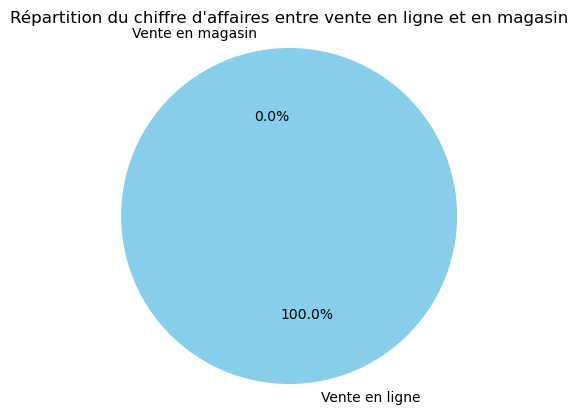

In [44]:
# Répartition du chiffre d'affaires entre vente en ligne et en magasin :

# Calcul du chiffre d'affaires pour la vente en ligne et en magasin
ca_en_ligne = round(merge_elw_both.loc[merge_elw_both['onsale_web'] == 1, 'price'].sum(), 2)
ca_en_magasin = round(merge_elw_both.loc[merge_elw_both['onsale_web'] == 0, 'price'].sum(), 2)

# Création du graphique en camembert
labels = ['Vente en ligne', 'Vente en magasin']
values = [ca_en_ligne, ca_en_magasin]

plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=100, colors=['skyblue', 'lightcoral'])
plt.axis('equal')  # Assure que le camembert est circulaire
plt.title('Répartition du chiffre d\'affaires entre vente en ligne et en magasin')
plt.show()

# Observation : comme nous l'avons vu précédemment, on se rend compte que les ventes en ligne sont la principale
# source de revenues (Donc nous allons analyser pour le reste la différence des prix entre les
# produit vendus en lignes et les produits vendus en magasin un peu plus bas)

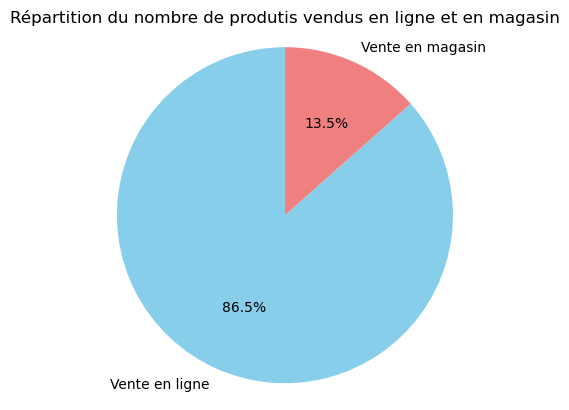

In [45]:
# Répartition du nombre de produits vendus en ligne et en magasin :

# Calcul du nombre de produits vendus en ligne et en magasin
nb_produits_magasin = len(merge_elw_left['sku']) # left_only = produits vendus en pdv physique (Valeurs = 0)
nb_produits_en_ligne = len(merge_elw_both['sku']) # both = produits vendus en ligne (Valeurs = 1)

# Création du graphique en camembert
labels = ['Vente en ligne', 'Vente en magasin']
values = [nb_produits_en_ligne, nb_produits_magasin]

plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.axis('equal')  # Assure que le camembert est circulaire
plt.title('Répartition du nombre de produtis vendus en ligne et en magasin')
plt.show()

# Comme nous n'avons pas d'informations sur les 111 produits vendus en magasin nous ne pouvons pas obtenir le CA 
# à partir de cette source. Cependant on peut voir la répartition des produits vendus en ligne et en magasin
# soit : 111(13.5%) produits vendus en magasin | 714(86.5%) produits vendus en ligne

## Analyse des valeurs aberrantes de la variable prix

### Prix des produits vendus en lignes : 

Q1 = 14.1
Q3 = 42.175000000000004
mediane = 23.55
moyenne = 32.49313725490196
bornes_inf = -28.012500000000003
bornes_sup = 84.28750000000001
IQR = 28.075000000000003
minimum = 5.2
maximum = 225.0


/Users/jordancanonne/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


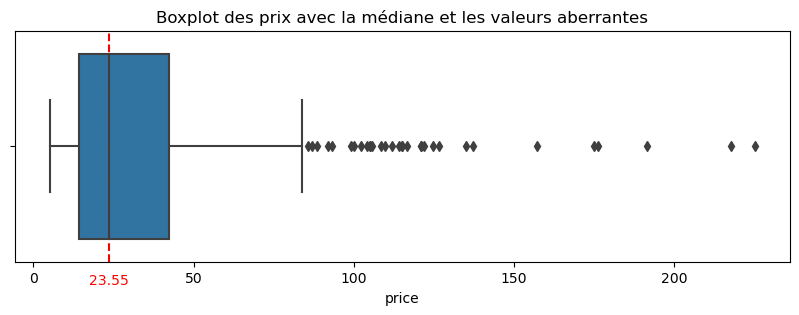

In [46]:
# Analyse des valeur aberrantes pour les produits vendus en lignes : 

Q1 = merge_elw_both['price'].quantile(0.25)
Q3 = merge_elw_both['price'].quantile(0.75)
IQR = Q3 - Q1
mediane = merge_elw_both['price'].median()
moyenne = merge_elw_both['price'].mean()


bornes_inf = Q1 - 1.5 * IQR
bornes_sup = Q3 + 1.5 * IQR

minimum = merge_elw_both['price'].min()
maximum = merge_elw_both['price'].max()

print("Q1 =",Q1)
print("Q3 =",Q3)
print("mediane =", mediane)
print("moyenne =", moyenne)
print("bornes_inf =",bornes_inf)
print("bornes_sup =",bornes_sup)
print("IQR =",IQR) # = zone centrale de notre distribution où la majorité de nos données se situe (valeur centrale entre Q1 et Q3)
print("minimum =",minimum)
print("maximum =",maximum)

# Création du boxplot avec la médiane et les valeurs aberrantes
plt.figure(figsize=(10, 3))  # Ajustez la taille du graphique selon vos préférences
sns.boxplot(x=merge_elw_both['price'])

# Ajouter une ligne pour représenter la médiane
plt.axvline(x=mediane, color='r', linestyle='--', label='Médiane')

plt.text(mediane, 0.58, f'{mediane}', color='r', ha='center', va='center')
plt.title("Boxplot des prix avec la médiane et les valeurs aberrantes")
plt.show()

In [47]:
# Affichage des valeurs aberrantes pour les produits vendus en ligne
valeurs_aberrantes = merge_elw_both[(merge_elw_both['price'] < bornes_inf) | (merge_elw_both['price'] > bornes_sup)]
print("On compte",valeurs_aberrantes.shape[0],"valeurs aberrantes")
display(valeurs_aberrantes)
# Obseration : Nous avons 32 valeurs aberrantes situées au dessus de la borne supérieur :  Vérification des prix 
# sur le web cohérent avec ces valeurs aberrantes de ce dataframe

# Cela reste cohérant avec le  marché dans lequel opère l'entreprise Bottleneck car le  marché des boissons alcoolisées 
# connaît des alcools d'exception qui font que le prix peut parfois être hors norme dans une sélection d'alcools
# allant d'alcool bons marchés aux grands cru


On compte 32 valeurs aberrantes


,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge
154,4115,1,100.0,11,instock,15382,0.0,2018-02-13 11:08:45,Zind-Humbrecht Riesling Grand Cru Rangen De Th...,product,both
156,4132,1,88.4,5,instock,11668,0.0,2018-02-13 11:43:55,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,product,both
291,4352,1,225.0,0,outofstock,15940,5.0,2018-03-02 10:30:04,Champagne Egly-Ouriet Grand Cru Millésimé 2008,product,both
293,4355,1,126.5,2,instock,12589,11.0,2018-03-02 10:46:10,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,product,both
297,4359,1,85.6,0,outofstock,13853,1.0,2018-03-02 11:11:48,Champagne Larmandier-Bernier Grand Cru Les Che...,product,both
310,4402,1,176.0,8,instock,3510,13.0,2018-03-22 11:21:05,Cognac Frapin VIP XO,product,both
311,4404,1,108.5,2,instock,3507,2.0,2018-03-22 11:32:55,Cognac Frapin Château de Fontpinot XO,product,both
313,4406,1,157.0,3,instock,7819,0.0,2018-03-22 11:42:48,Cognac Frapin Château de Fontpinot 1989 20 Ans...,product,both
314,4407,1,104.0,6,instock,3509,1.0,2018-03-22 11:49:53,Cognac Frapin Cigar Blend,product,both
320,4582,1,109.6,7,instock,12857,0.0,2018-04-12 17:56:13,Château de Meursault Puligny-Montrachet 1er Cr...,product,both


### Prix des produits vendus en magasin : 

Q1 = 21.0
Q3 = 40.0
mediane = 30.0
moyenne = 32.33963963963965
bornes_inf = -7.5
bornes_sup = 68.5
IQR = 19.0
minimum = 8.3
maximum = 144.0


/Users/jordancanonne/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


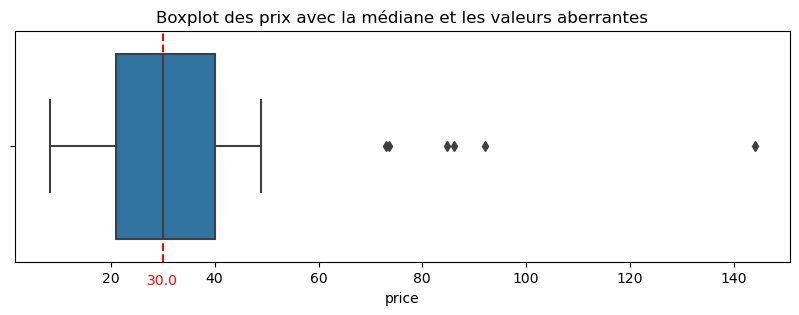

In [48]:
# Analyse des valeur aberrantes pour les produits vendus en magasins : 

Q1 = merge_elw_left['price'].quantile(0.25)
Q3 = merge_elw_left['price'].quantile(0.75)
IQR = Q3 - Q1
mediane = merge_elw_left['price'].median()
moyenne = merge_elw_left['price'].mean()


bornes_inf = Q1 - 1.5 * IQR
bornes_sup = Q3 + 1.5 * IQR

minimum = merge_elw_left['price'].min()
maximum = merge_elw_left['price'].max()

print("Q1 =",Q1)
print("Q3 =",Q3)
print("mediane =", mediane)
print("moyenne =", moyenne)
print("bornes_inf =",bornes_inf)
print("bornes_sup =",bornes_sup)
print("IQR =",IQR) # = zone centrale de notre distribution où la majorité de nos données se situe (valeur centrale entre Q1 et Q3)
print("minimum =",minimum)
print("maximum =",maximum)

# Création du boxplot avec la médiane et les valeurs aberrantes
plt.figure(figsize=(10, 3))  # Ajustez la taille du graphique selon vos préférences
sns.boxplot(x=merge_elw_left['price'])

# Ajouter une ligne pour représenter la médiane
plt.axvline(x=mediane, color='r', linestyle='--', label='Médiane')


plt.text(mediane, 0.58, f'{mediane}', color='r', ha='center', va='center')
plt.title("Boxplot des prix avec la médiane et les valeurs aberrantes")
plt.show()

In [49]:
# Affichage des valeurs aberrantes pour les produits vendus en magasin
valeurs_aberrantes = merge_elw_left[(merge_elw_left['price'] < bornes_inf) | (merge_elw_left['price'] > bornes_sup)]
print("On compte",valeurs_aberrantes.shape[0],"valeurs aberrantes")
display(valeurs_aberrantes)
# Obseration : Nous avons 6 valeurs aberrantes situées au dessus de la borne supérieur. Ici c'est différent par 
# rapport à notre analyse précédente sur les vins vendus en ligne car nous n'avons pas leur titre, il est donc plus
# difficile d'identifier la cohérence avec leurs prix. Mais nous pouvons toujours garder à l'idée qu'il est courant
# de voir des prix aberrants sur le marché des boissons alcoolisées. 

# On pourrait extrapoler en multipliant par 6.5 le nombre total de produits vendus en magasin pour se rapprocher de 
# celui vendus en ligne, soit: 111*6.5 = 721.5 , et que l'on ferait la meme chose pour les valeurs aberrantes, soit:
# 6*6.5 = 39 valeurs aberrantes. 

# Conclusion, nous aurions potentiellement 39 valeurs aberrantes pour les produits vendus en magasins contre 
# 32 valeurs aberrantes des produits vendus en lignes. Cette observation demeure relativement cohérente avec 
# le nombre de prix aberrants existants pour une quantité donnée de produits sur le marché des boissons alcoolisées


On compte 6 valeurs aberrantes


,product_id,onsale_web,price,stock_quantity,stock_status,sku,total_sales,post_date,post_title,post_type,_merge
19,4055,0,86.1,1,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
20,4090,0,73.0,6,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
23,4209,0,73.5,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
30,4594,1,144.0,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
47,5070,1,84.7,0,outofstock,NaN,NaN,NaT,NaN,NaN,left_only
55,6324,0,92.0,18,instock,NaN,NaN,NaT,NaN,NaN,left_only


# Annexes 

In [50]:
# Bref Benchmark pour les deux vins manquants :
# Pierre Jean Villa Condrieu Jardin Suspendu 2018 ≈ 45 - 50 €. Sources : 
    # - 45€ : https://diogene-atmosphere.com/produit/condrieu-jardin-suspendu-blanc-2018-pierre-jean-villa-vallee-du-rhone/
    # - 50€ : https://www.lepetitballon.com/pierre-jean-villa-jardin-suspendu-2018.html
    
# Pierre Jean Villa Côte Rôtie Fongeant 2017 ≈ 91 - 110 € . Sources :
    # - 91€ : https://www.grandsbourgognes.com/fr/domaine-pierre-jean-villa/c%C3%B4te-r%C3%B4tie-fongeant-5723.html
    # - 110€ : https://diogene-atmosphere.com/produit/cote-rotie-fongeant-rouge-2017-pierre-jean-villa-vallee-du-rhone/

Moyenne:
 32.49313725490196


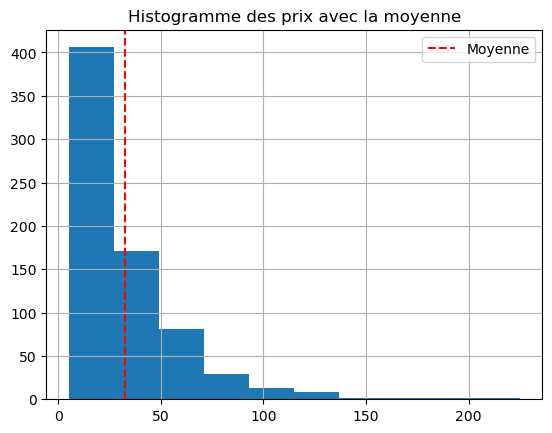

In [51]:
# Histogramme des prix
mean_price = merge_elw_both['price'].mean()
print("Moyenne:\n", mean_price)

# Création de l'histogramme
merge_elw_both["price"].hist()

# Ajout d'une ligne verticale pour représenter la moyenne sur l'histogramme
plt.axvline(x=mean_price, color='r', linestyle='--', label='Moyenne')

# Ajout d'autres éléments de la visualisation (titres, légendes)
plt.title("Histogramme des prix avec la moyenne")
plt.legend()

In [52]:
# Si nous pouvions modifier les valeurs des sku manquants par de vrai sku voilà une fonction pour :
# générer une clé à 5 chiffres unique (non présente dans la colonne 'sku' ou autre, personnaliser)
def generer_valeur_unique():
    while True:
        nouvelle_valeur = np.random.randint(10000, 100000)
        if nouvelle_valeur not in web['sku'].values:
            return nouvelle_valeur

# Génération de la valeur aléatoire unique
nouvelle_valeur_unique = generer_valeur_unique()
nouvelle_valeur_unique

# Ajout de la nouvelle valeur en choisissant l'index dans le df web : web.at[353, 'sku'] = nouvelle_valeur_unique
# Pareil pour la deuxième valeur : web.at[488, 'sku'] = nouvelle_valeur_unique

44437

In [53]:
# Pour montrer un maximum de colonnes dans jupyter notebook : 
pd.set_option('display.max_columns', None)